# Практика по Кластеризации К-Средних
Данные - `/DATA/bank-full.csv`

Тут представлены клиенты банка

Задача - Объединить клиентов в некоторые кластеры

-----
В задачах обучения без учителя у нас отсутствует целевая переменная, поэтому необходимо глубокое знание предметной области, чтобы самому делать какие-то выводы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Exploratory Data Analysis

In [2]:
df = pd.read_csv('~//Documents//University//Анализ данных//'
                 '1. ML Course ipynb//DATA//bank-full.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
'Для начала изучаю только непрерывные переменные'
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
'Теперь категориальные переменные'
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### 1.1 Visualisation

<Axes: xlabel='age', ylabel='Count'>

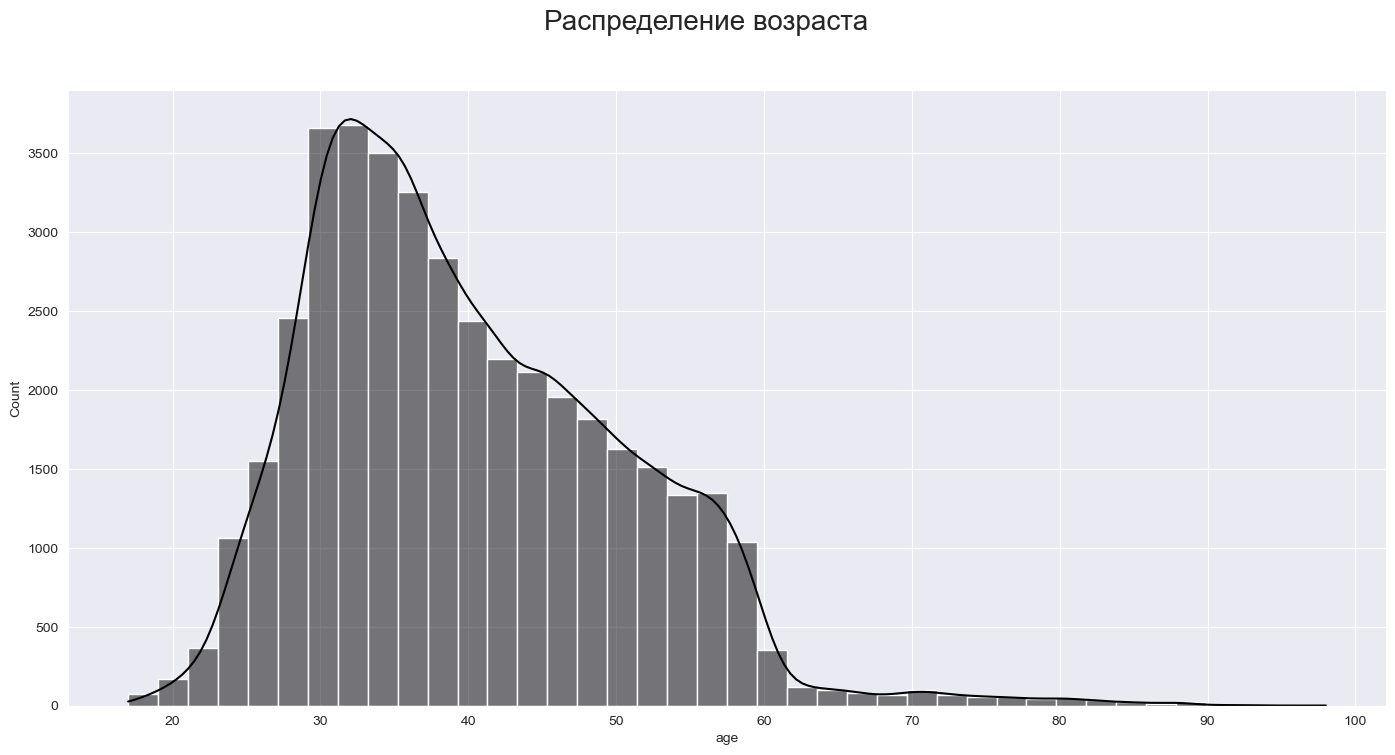

In [6]:
plt.figure(figsize=(17,8))
plt.suptitle('Распределение возраста', fontsize=20)
sns.histplot(data=df, x='age', bins=40, kde=True, color='black')

<Axes: xlabel='age', ylabel='Count'>

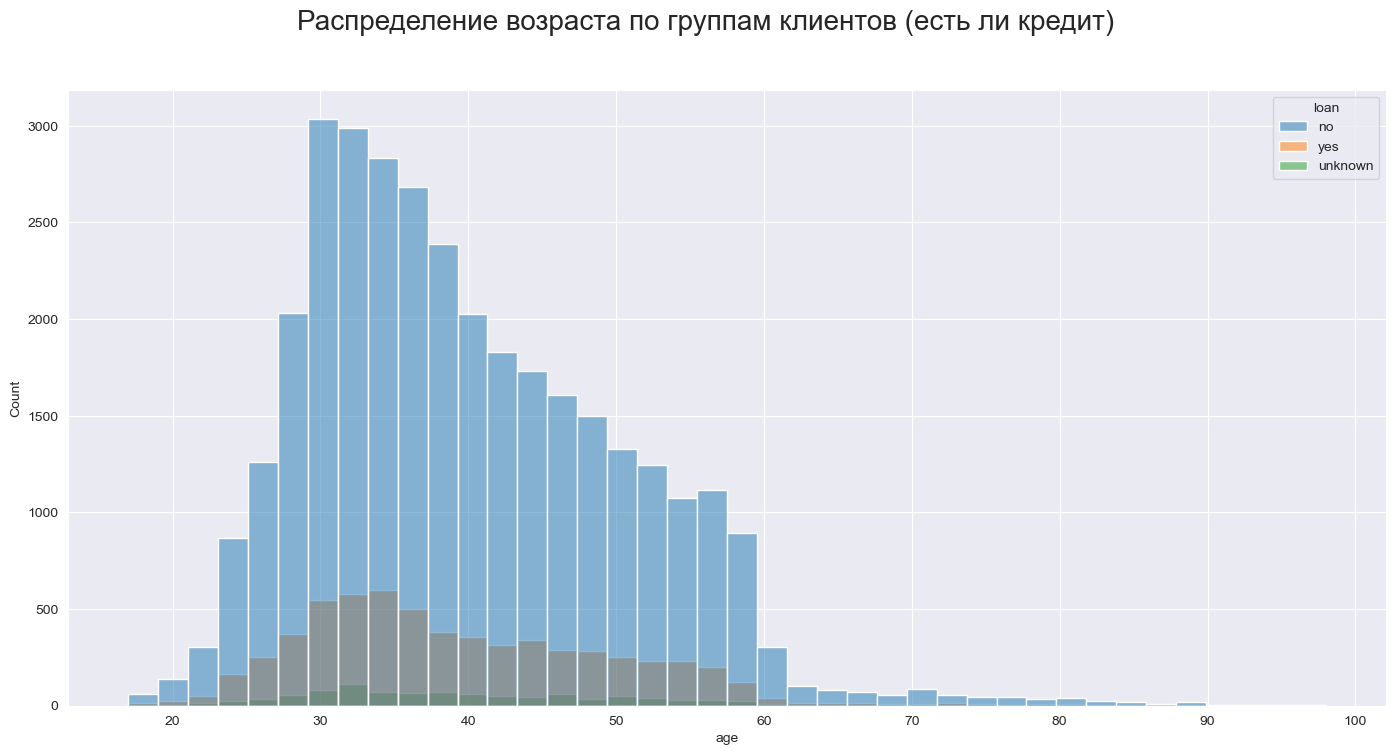

In [7]:
plt.figure(figsize=(17,8))
plt.suptitle('Распределение возраста по группам клиентов (есть ли кредит)', fontsize=20)
sns.histplot(data=df, x='age', bins=40, hue='loan')

`pdays` - Сколько дней назад контактировали с клиентом по маркетинговым вопросам. Если `pdays` = 999 это значит, что с клиентом никогда не общались.

<Axes: xlabel='pdays', ylabel='Count'>

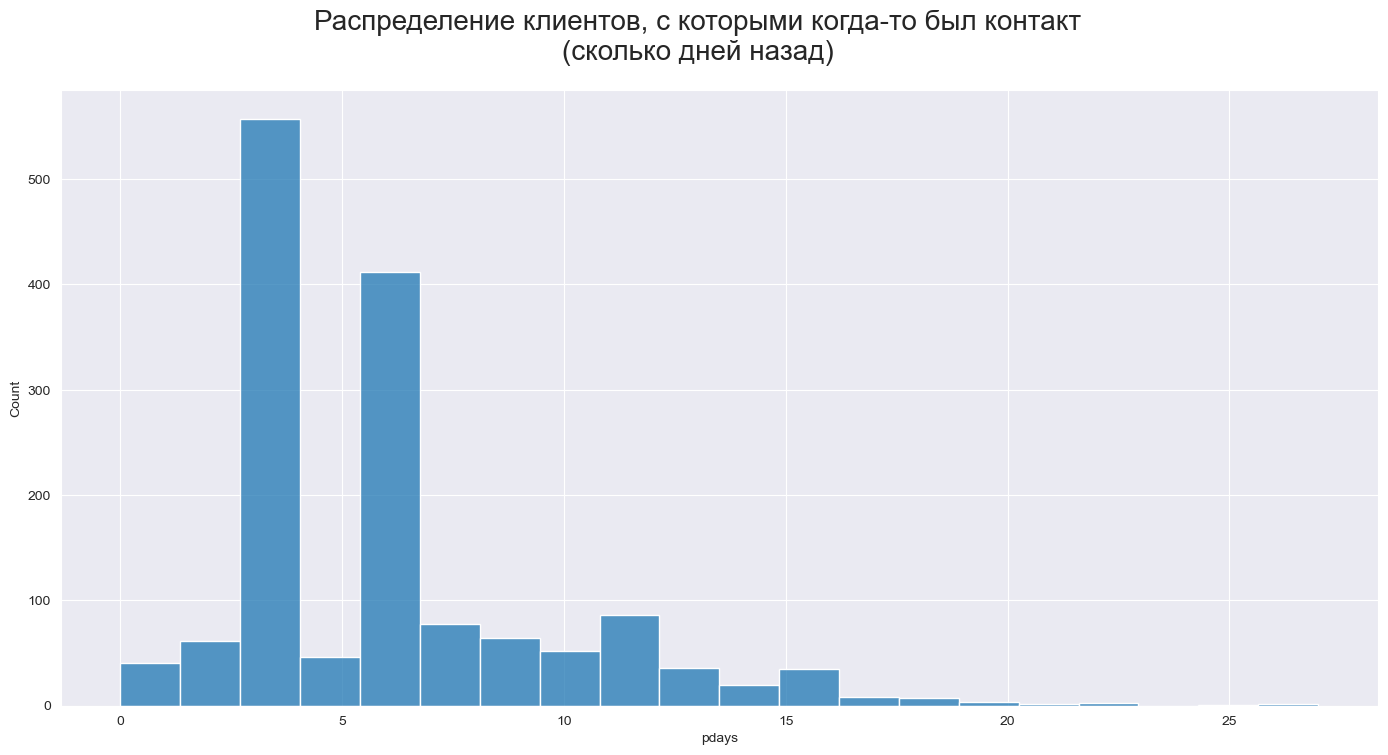

In [8]:
plt.figure(figsize=(17,8))
plt.suptitle('Распределение клиентов, с которыми когда-то был контакт\n(сколько дней назад)', fontsize=20)
sns.histplot(data=df[df['pdays'] != 999], x='pdays', bins=20)

- `duration` - Сколько секунд разговаривали с клиентом.
- `contact` - Как связывались с клиентом.
    1. `telephone` - По мобильному телефону
    2. `cellular` - По стационарному телефону.

(0.0, 1000.0)

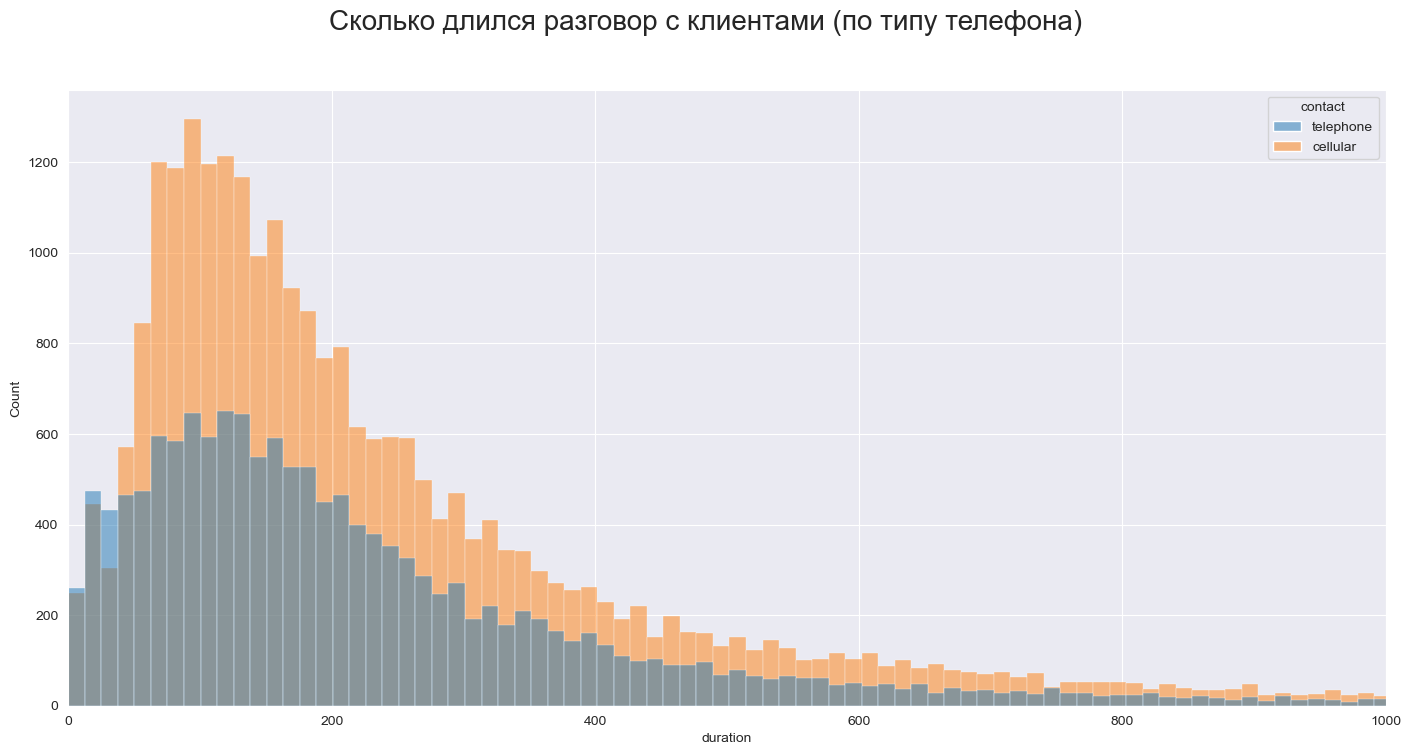

In [9]:
plt.figure(figsize=(17,8))
plt.suptitle('Сколько длился разговор с клиентами (по типу телефона)', fontsize=20)
sns.histplot(data=df, x='duration', hue='contact')
plt.xlim(0, 1000)

<Axes: xlabel='contact', ylabel='count'>

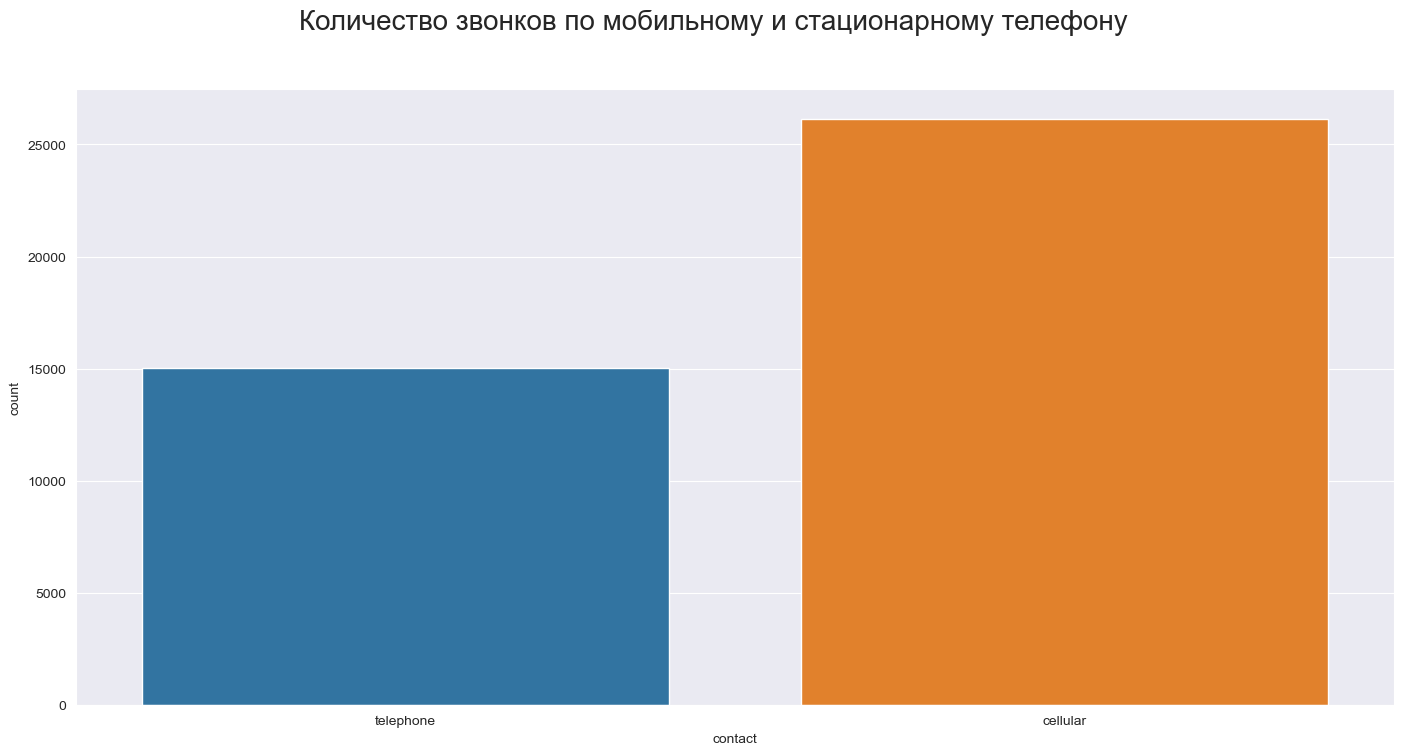

In [10]:
plt.figure(figsize=(17,8))
plt.suptitle('Количество звонков по мобильному и стационарному телефону', fontsize=20)
sns.countplot(data=df, x='contact', hue='contact')

Посмотрим на категориальные переменные

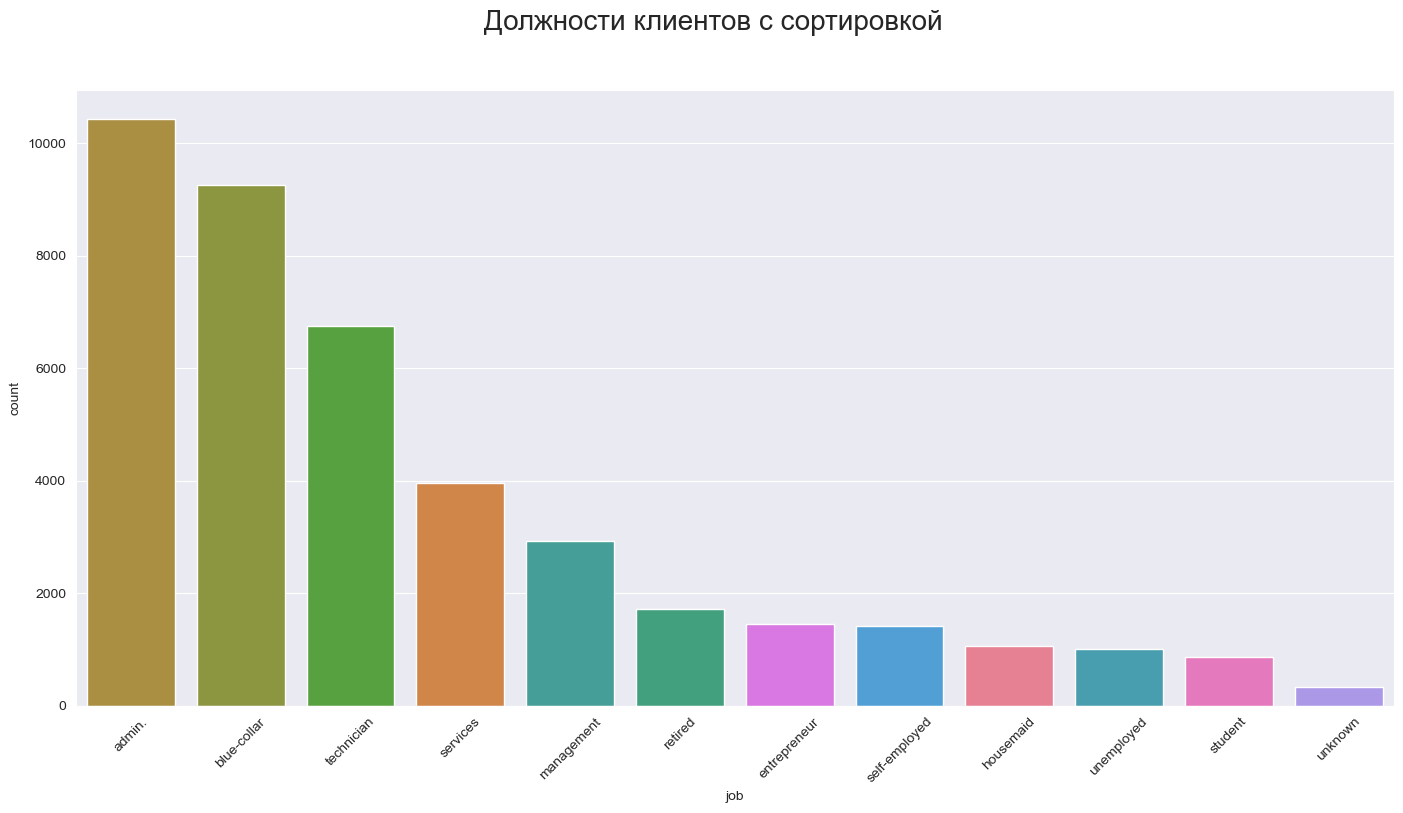

In [11]:
plt.figure(figsize=(17,8))
plt.suptitle('Должности клиентов с сортировкой', fontsize=20)
sns.countplot(data=df, x='job', hue='job',
              order=df['job'].value_counts().index # Даю сортировку по количеству
              )
plt.xticks(rotation=45);

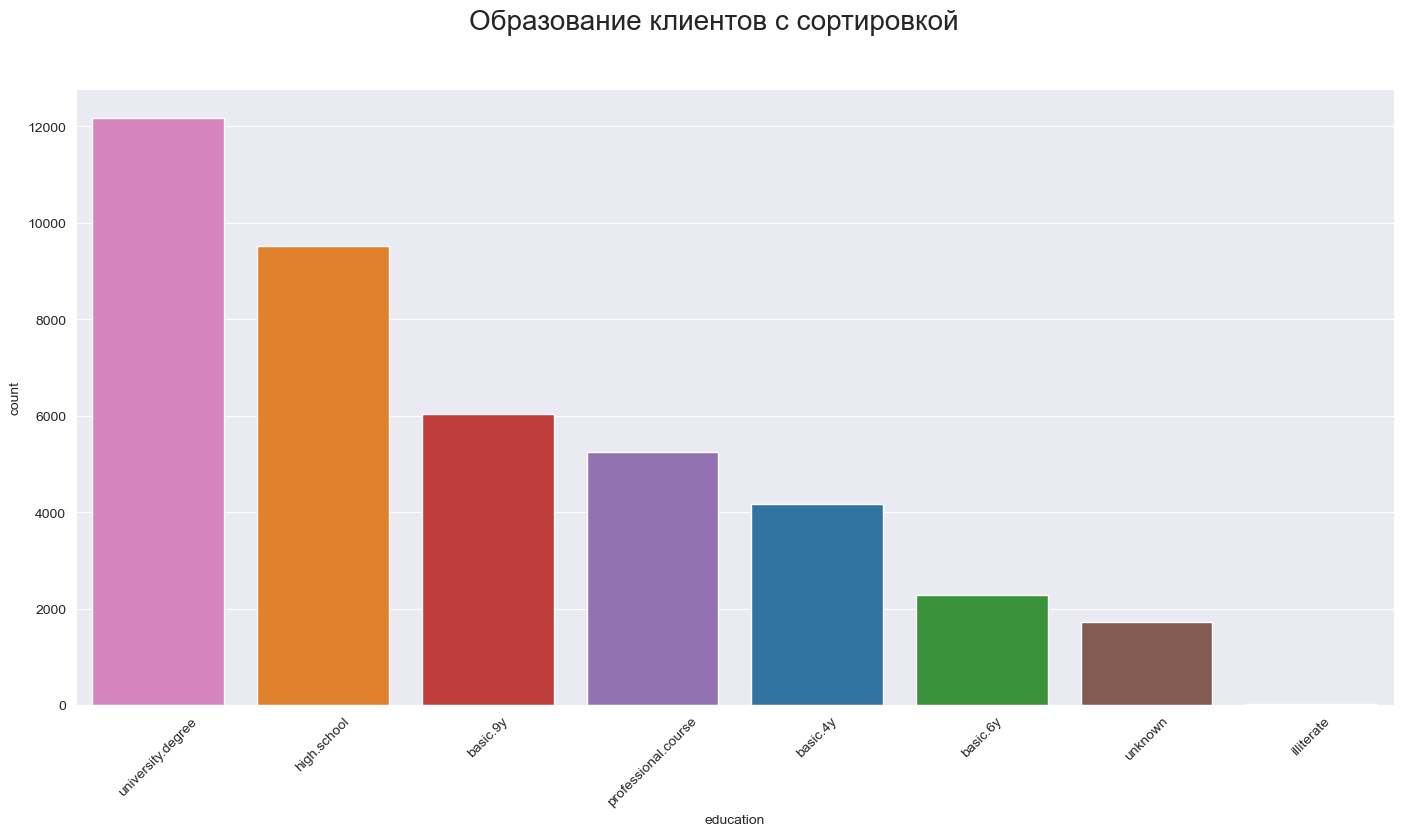

In [12]:
plt.figure(figsize=(17,8))
plt.suptitle('Образование клиентов с сортировкой', fontsize=20)
sns.countplot(data=df, x='education', hue='education', order=df['education'].value_counts().index)
plt.xticks(rotation=45);

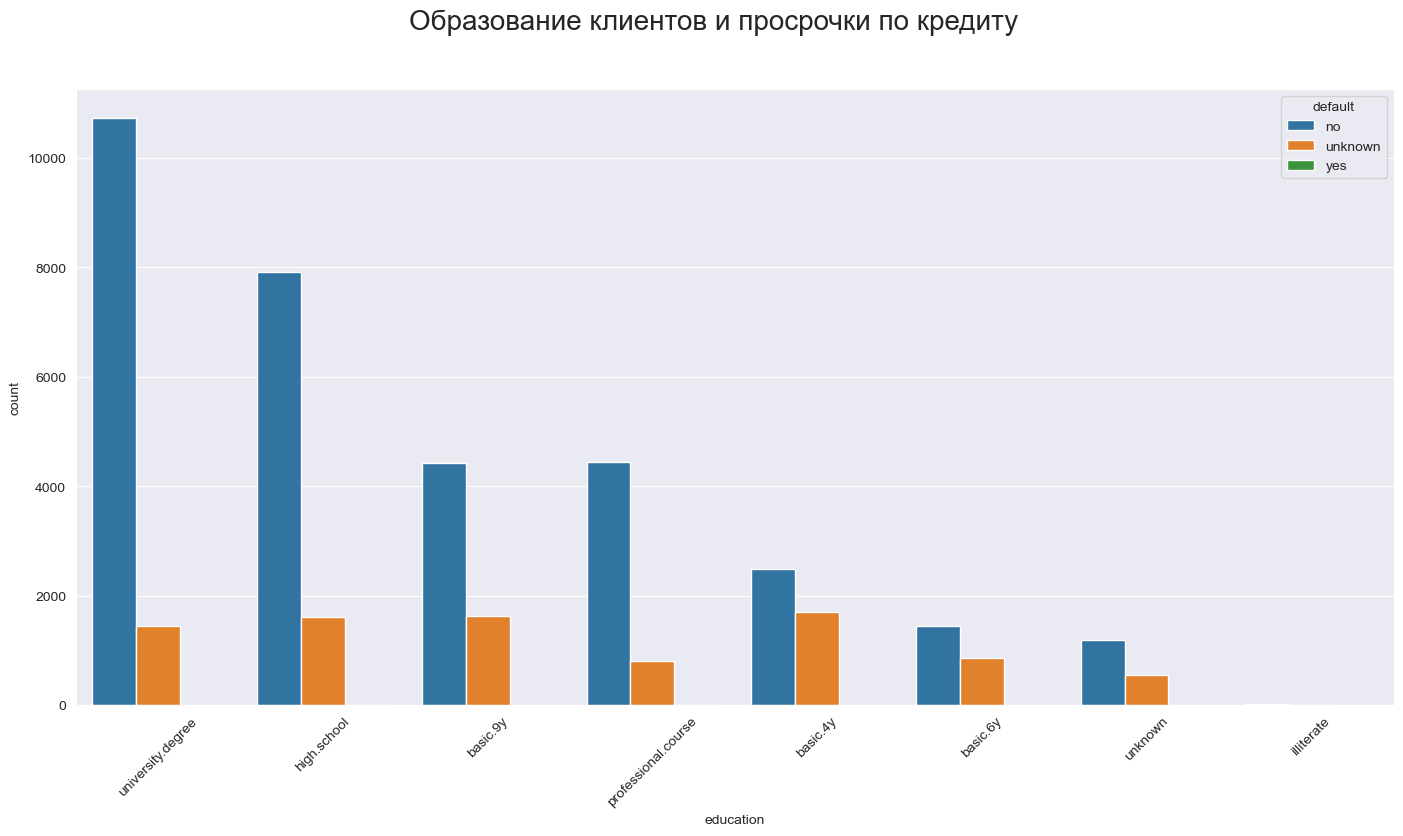

In [13]:
plt.figure(figsize=(17,8))
plt.suptitle('Образование клиентов и просрочки по кредиту', fontsize=20)
sns.countplot(data=df, x='education', hue='default', order=df['education'].value_counts().index)
plt.xticks(rotation=45);

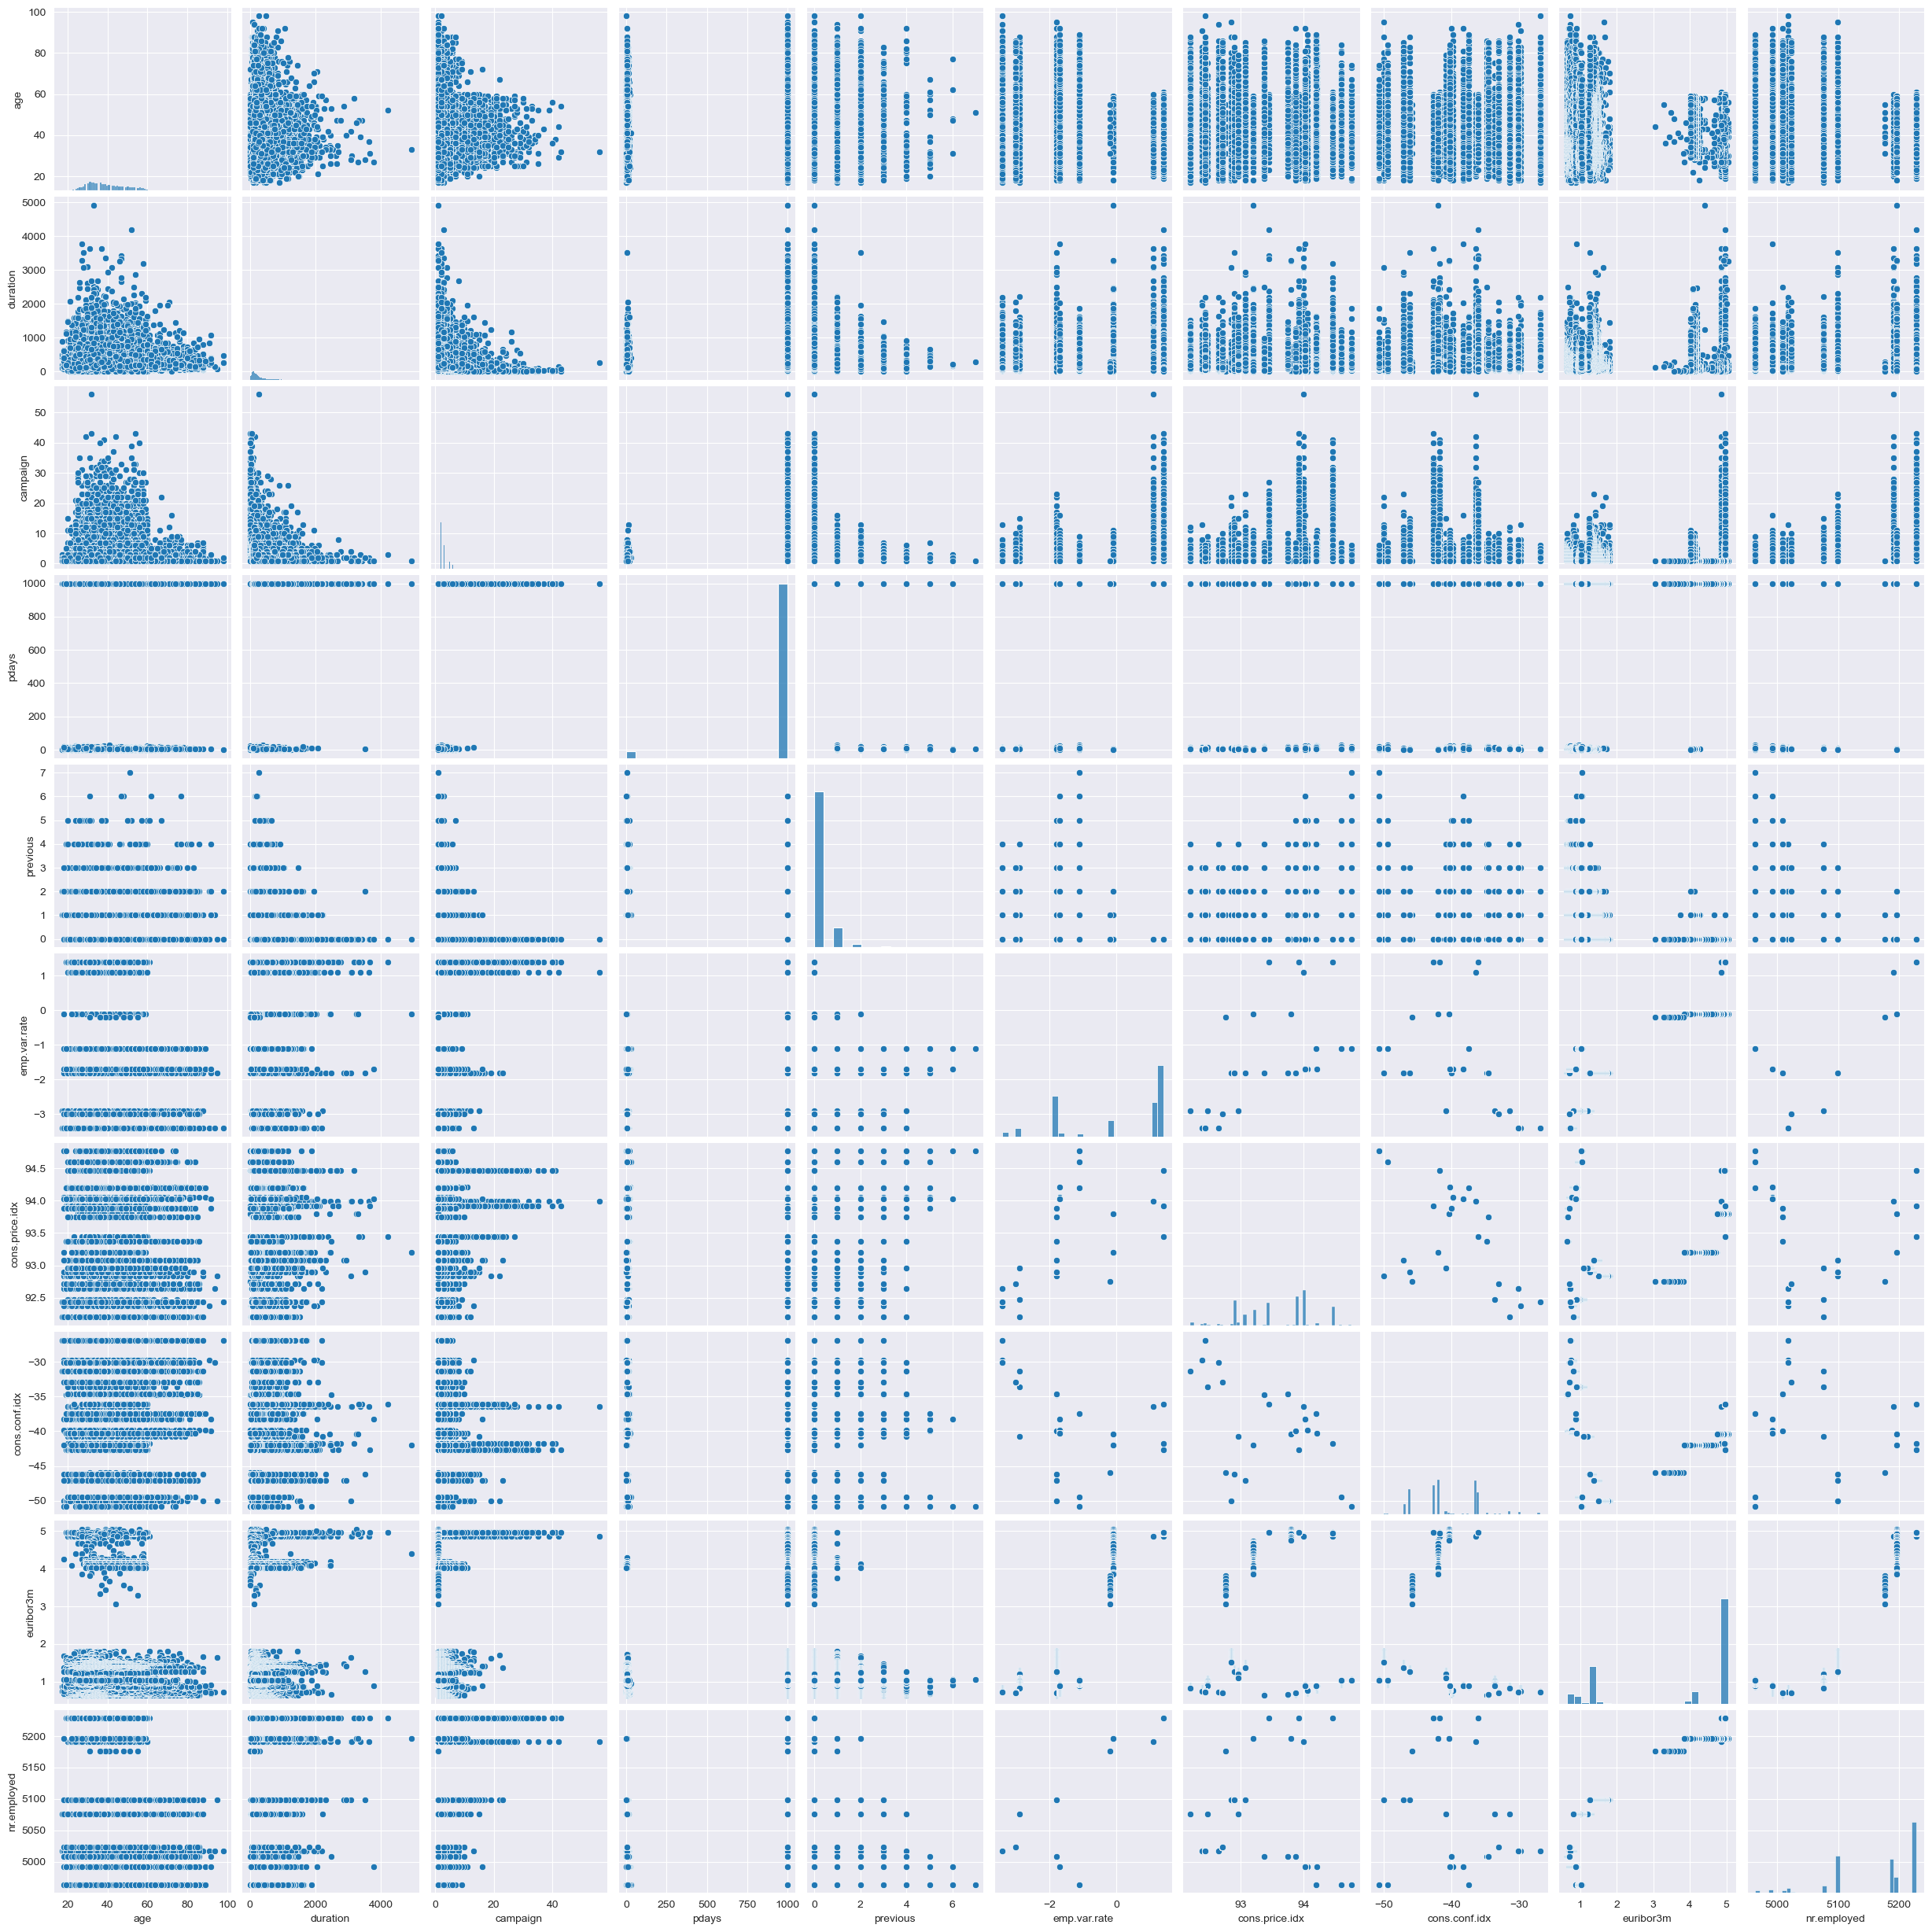

In [14]:
sns.pairplot(data=df)

## 2. Подготовка данных и обучение модели
У нас достаточно много категориальных переменных, поэтому будем делать `dummy`-переменные.

In [15]:
X = pd.get_dummies(df)
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True


Теперь можно нормализовать (или масштабировать) признаки. Чтобы все признаки измерялись в общей шкале.

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

scaled_X

array([[ 1.53303429,  0.01047142, -0.56592197, ..., -0.1857    ,
         0.35630932, -0.35630932],
       [ 1.62899323, -0.42150051, -0.56592197, ..., -0.1857    ,
         0.35630932, -0.35630932],
       [-0.29018564, -0.12451981, -0.56592197, ..., -0.1857    ,
         0.35630932, -0.35630932],
       ...,
       [ 1.53303429, -0.26722482, -0.20490853, ..., -0.1857    ,
         0.35630932, -0.35630932],
       [ 0.38152696,  0.70856893, -0.56592197, ..., -0.1857    ,
        -2.80655022,  2.80655022],
       [ 3.26029527, -0.07438021,  0.15610492, ..., -0.1857    ,
         0.35630932, -0.35630932]])

In [17]:
from sklearn.cluster import KMeans
# help(KMeans)

In [18]:
'Создаем модель с двумя кластерами (кому будем отправлять маркетинговые предложения и кому нет)'
model = KMeans(n_clusters=2)

Теперь у нас есть несколько вариантов:
1. `model.fit(X)` - Чтобы вычислить кластеры
2. `model.predict(n)` - Передаем строку и получаем ближайший кластер для этой точки
3. `model.fit_predict(X)` - Чтобы вычислить кластеры и вернуть значения кластеров для наших точек
4. `model.fit_transform(X)` - Вычислит кластеры и вернет расстояния от точек до центров кластеров


In [19]:
cluster_labels = model.fit_predict(scaled_X)
cluster_labels

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [20]:
X['Cluster'] = cluster_labels # Это по сути и есть переменная y, которую мы создали сами
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,Cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,0
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,0
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,0
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,0


Теперь можно посмотреть корреляции признаков с колонкой `cluster`

In [21]:
'Сильная положительная корреляция'
X.corr()['Cluster'].sort_values(ascending=False)

Cluster             1.000000
euribor3m           0.959267
emp.var.rate        0.932603
nr.employed         0.886120
cons.price.idx      0.679394
                      ...   
subscribed_yes     -0.294748
month_apr          -0.357904
contact_cellular   -0.410508
poutcome_failure   -0.464271
previous           -0.478442
Name: Cluster, Length: 66, dtype: float64

In [22]:
'Сильная отрицательная корреляция'
X.corr()['Cluster'].sort_values()

previous           -0.478442
poutcome_failure   -0.464271
contact_cellular   -0.410508
month_apr          -0.357904
subscribed_yes     -0.294748
                      ...   
cons.price.idx      0.679394
nr.employed         0.886120
emp.var.rate        0.932603
euribor3m           0.959267
Cluster             1.000000
Name: Cluster, Length: 66, dtype: float64

<Axes: >

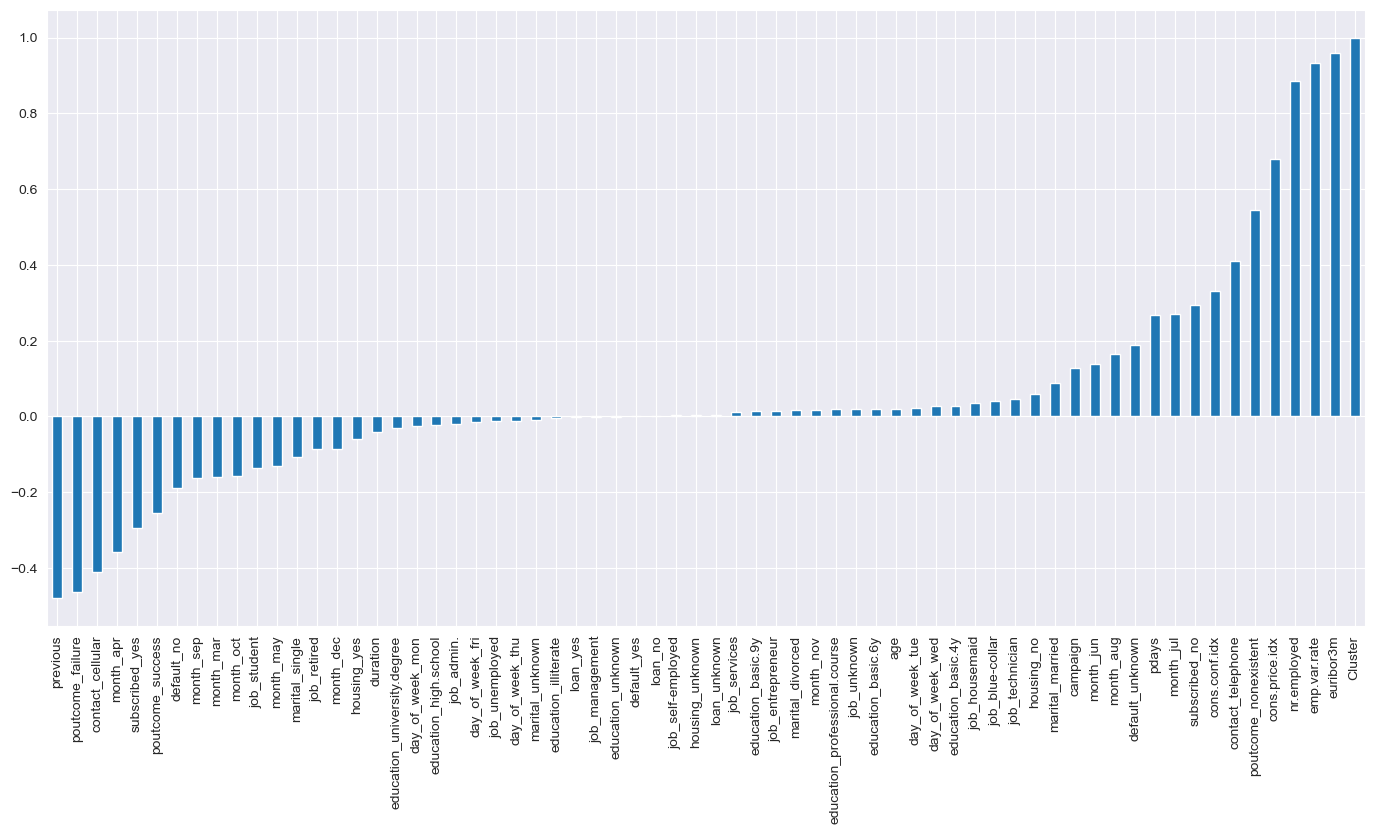

In [23]:
plt.figure(figsize=(17,8))
X.corr()['Cluster'].sort_values().plot(kind='bar')